# Speech Emotion Recognition using CNN

This project implements a Speech Emotion Recognition (SER) system using Deep Learning techniques. The model is trained on the RAVDESS dataset and classifies emotions from audio signals.

Author: Marcio da Costa Oliveira

In [1]:
!pip install librosa

In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten, MaxPooling1D
from tensorflow.keras.utils import to_categorical

sns.set()
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [3]:
!wget https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip
!unzip Audio_Speech_Actors_01-24.zip -d data

--2026-03-24 09:41:56--  https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip
Resolving zenodo.org (zenodo.org)... 188.185.48.75, 188.184.98.114, 137.138.52.235, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.75|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/1188976/files/Audio_Speech_Actors_01-24.zip [following]
--2026-03-24 09:41:57--  https://zenodo.org/records/1188976/files/Audio_Speech_Actors_01-24.zip
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 208468073 (199M) [application/octet-stream]
Saving to: ‘Audio_Speech_Actors_01-24.zip’

Audio_Speech_Actors 100%[===================>] 198.81M   956KB/s    in 4m 21s  

2026-03-24 09:46:18 (780 KB/s) - ‘Audio_Speech_Actors_01-24.zip’ saved [208468073/208468073]

Archive:  Audio_Speech_Actors_01-24.zip
   creating: data/Actor_01/
  inflating: data/Actor_01/03-01-01-01-01-01-01.wav  
  inflating: data/Actor_01

In [4]:
data_path = "data"

emotions = []
paths = []

def extract_emotion_from_filename(filename):
    emotion_code = int(filename.split("-")[2])

    emotion_map = {
        1: "neutral",
        2: "calm",
        3: "happy",
        4: "sad",
        5: "angry",
        6: "fearful",
        7: "disgust",
        8: "surprised"
    }

    return emotion_map.get(emotion_code)

for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.endswith(".wav"):
            emotion = extract_emotion_from_filename(file)
            path = os.path.join(root, file)

            emotions.append(emotion)
            paths.append(path)

df = pd.DataFrame({
    "emotion": emotions,
    "path": paths
})

df.head()

,emotion,path
0,happy,data/Actor_02/03-01-03-02-01-01-02.wav
1,disgust,data/Actor_02/03-01-07-02-02-01-02.wav
2,fearful,data/Actor_02/03-01-06-01-01-01-02.wav
3,sad,data/Actor_02/03-01-04-01-02-02-02.wav
4,neutral,data/Actor_02/03-01-01-01-02-01-02.wav


In [5]:
def extract_features(file_path):
    audio, sample_rate = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    return np.mean(mfcc.T, axis=0)

features = []

for path in tqdm(df["path"]):
    try:
        data = extract_features(path)
        features.append(data)
    except:
        features.append(None)

df["features"] = features
df = df.dropna()

100%|██████████| 1440/1440 [01:11<00:00, 20.02it/s]


In [6]:
X = np.array(df["features"].tolist())
y = np.array(df["emotion"].tolist())

encoder = LabelEncoder()
y_encoded = to_categorical(encoder.fit_transform(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

X_train = X_train[:, :, np.newaxis]
X_test = X_test[:, :, np.newaxis]

In [7]:
model = Sequential()

model.add(Conv1D(64, 5, activation='relu', input_shape=(X_train.shape[1], 1)))
model.add(Conv1D(128, 5, activation='relu', padding='same'))
model.add(MaxPooling1D(5))

model.add(Conv1D(256, 5, activation='relu', padding='same'))
model.add(MaxPooling1D(5))
model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dense(y_encoded.shape[1], activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 36, 64)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 36, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 7, 256)         │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,536 (869.28 KB)

 Trainable params: 222,536 (869.28 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.1354 - loss: 4.3577 - val_accuracy: 0.1840 - val_loss: 2.1619
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.1554 - loss: 2.2181 - val_accuracy: 0.2083 - val_loss: 2.0220
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.2101 - loss: 2.0047 - val_accuracy: 0.2604 - val_loss: 1.9542
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.2370 - loss: 1.9539 - val_accuracy: 0.2604 - val_loss: 1.8962
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.2509 - loss: 1.8943 - val_accuracy: 0.2118 - val_loss: 1.8627
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.2665 - loss: 1.8694 - val_accuracy: 0.2743 - val_loss: 1.8321
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.2917 - loss: 1.8280 - val_accuracy: 0.3056 - val_loss: 1.8123
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.2986 - loss: 1.7720 - val_accuracy: 0.3021 - 

In [9]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6181 - loss: 1.1856
Accuracy: 0.6180555820465088


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


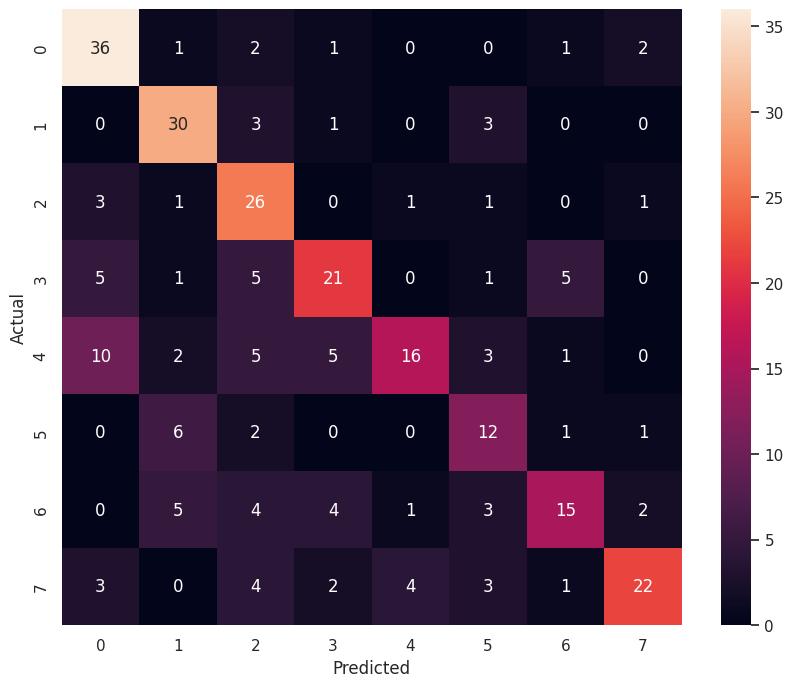

In [10]:
predictions = model.predict(X_test)
predictions = np.argmax(predictions, axis=1)

y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
model.save("ser_model.h5")